In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import control as ct
import math
import seaborn as sns

# Agar plot muncul inline di notebook
%matplotlib inline 

# Konfigurasi ukuran plot default agar terbaca jelas
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

In [2]:
# 1. DEFINISI PARAMETER FISIS (Sesuai Datasheet)
Ra = 1.8           # Ohm
La = 0.00104       # Henry
Kt = 0.046         # Nm/A
Kb = 0.028         # V/(rad/s)
J  = 0.0000017     # kg.m^2
b  = 0.0000048     # N.m.s/rad
TL = 0             # Nm (Torsi Beban)

# Parameter Simulasi Global
Vin_max = 75       # Volt
Tsim    = 3.0      # Detik
dt_plot = 0.001    # Time step plotting (1 ms)
t       = np.arange(0, Tsim + dt_plot, dt_plot)

# Hitung Koefisien Fungsi Alih (G(s) = speed / voltage)
# Persamaan diferensial orde 2
den_s2 = La * J
den_s1 = Ra * J + La * b
den_s0 = Ra * b + Kt * Kb

--- Analisis Skenario 1: Open Loop Response ---
Final Speed (Steady State) : 2660.7231 rad/s
Rise Time (Tr - 10% to 90%): 0.0040 s
Settling Time (Ts - 2%)    : 0.0070 s
Overshoot (%OS)            : 0.00 %


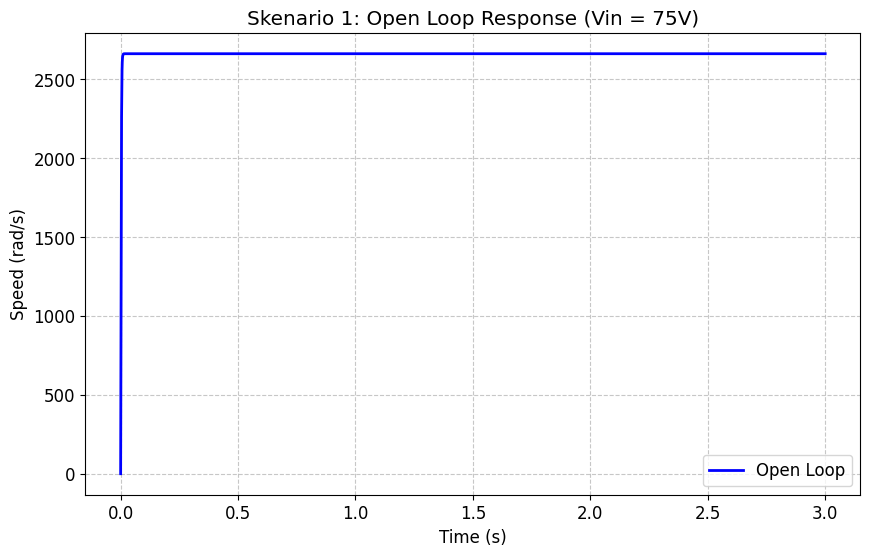

In [3]:
print('--- Analisis Skenario 1: Open Loop Response ---')

# G(s) = Kt / (den_s2*s^2 + den_s1*s + den_s0)
sys_tf = ct.tf([Kt], [den_s2, den_s1, den_s0])

# Simulasi Step Response
t_ol, y_ol_unit = ct.step_response(sys_tf, T=t)
y_ol = y_ol_unit * Vin_max

# --- PERHITUNGAN MANUAL METRIK TRANSIEN ---
y_final = y_ol[-1]  # Steady State value

# 1. Rise Time (Waktu dari 10% ke 90% final value)
idx_10 = np.argmax(y_ol >= 0.1 * y_final)
idx_90 = np.argmax(y_ol >= 0.9 * y_final)

if idx_10 == 0 and y_ol[0] < 0.1 * y_final:
     Tr = float('nan')
else:
     Tr = t_ol[idx_90] - t_ol[idx_10]

# 2. Settling Time (Waktu terakhir sinyal berada di luar toleransi 2%)
tolerance = 0.02 * y_final
is_outside = np.abs(y_ol - y_final) > tolerance
idx_settled_tuple = np.where(is_outside)[0]

if len(idx_settled_tuple) == 0:
    Ts = 0
else:
    idx_settled = idx_settled_tuple[-1]
    Ts = t_ol[idx_settled + 1] if (idx_settled + 1 < len(t_ol)) else t_ol[-1]

# 3. Overshoot
y_max = np.max(y_ol)
OS = (y_max - y_final) / y_final * 100 if y_max > y_final else 0

# Output Teks
print(f'Final Speed (Steady State) : {y_final:.4f} rad/s')
print(f'Rise Time (Tr - 10% to 90%): {Tr:.4f} s')
print(f'Settling Time (Ts - 2%)    : {Ts:.4f} s')
print(f'Overshoot (%OS)            : {OS:.2f} %')

# Plotting
plt.figure()
plt.plot(t_ol, y_ol, linewidth=2, color='b', label='Open Loop')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.title(f'Skenario 1: Open Loop Response (Vin = {Vin_max}V)')
plt.xlabel('Time (s)')
plt.ylabel('Speed (rad/s)')
plt.legend()
plt.show()

--- Analisis Skenario 2: PID Control + Anti-Windup ---
Simulasi PID selesai.
Setpoint           : 2000.00 rad/s
Final Speed        : 1999.84 rad/s
Steady State Error : 0.1614 rad/s


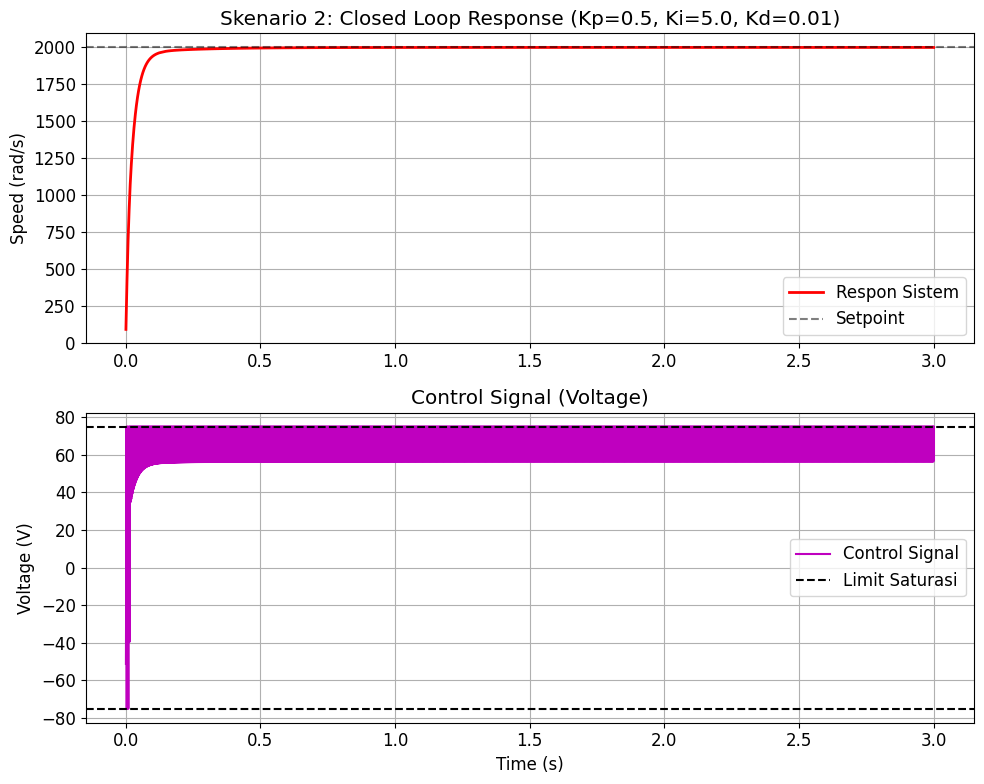

In [4]:
print('--- Analisis Skenario 2: PID Control + Anti-Windup ---')

# === TUNING PID DI SINI ===
Kp = 0.5
Ki = 5.0
Kd = 0.01
Setpoint = 2000  # rad/s
# ==========================

# Setup Simulasi Presisi Tinggi (Manual Euler Integration)
dt_calc = 0.00001 # 10 mikrosekon
steps = int(math.floor(Tsim / dt_calc))

# List untuk penyimpanan data
w_plot = []
u_plot = []
t_plot = []

# Inisialisasi State Variable
w = 0.0
curr = 0.0
integral_term = 0.0
prev_error = 0.0
counter = 0

# Mulai Loop Fisika
for k in range(steps):
    # 1. PID Calculation
    error = Setpoint - w
    P = Kp * error
    D = Kd * (error - prev_error) / dt_calc
    
    v_raw = P + integral_term + D
    
    # 2. Saturasi (Limit Tegangan)
    is_sat = False
    if v_raw > Vin_max:
        v_out = Vin_max
        is_sat = True
    elif v_raw < -Vin_max:
        v_out = -Vin_max
        is_sat = True
    else:
        v_out = v_raw
        is_sat = False
        
    # 3. Anti-Windup (Clamping Logic)
    # Integral hanya aktif jika tidak saturasi, ATAU jika error membantu keluar dari saturasi
    is_helping = (v_raw * error < 0)
    
    if (not is_sat) or is_helping:
        integral_term += Ki * error * dt_calc
        
    # 4. Fisika Motor (Euler Integration)
    # dw/dt = (Kt*i - b*w - Tload) / J
    dw = (Kt * curr - b * w - TL) / J
    # di/dt = (V - R*i - Kb*w) / L
    di = (v_out - Ra * curr - Kb * w) / La
    
    w += dw * dt_calc
    curr += di * dt_calc
    prev_error = error
    
    # 5. Downsampling (Simpan data setiap 1ms agar grafik tidak berat)
    counter += 1
    if counter >= (dt_plot / dt_calc):
        w_plot.append(w)
        u_plot.append(v_out)
        t_plot.append(k * dt_calc)
        counter = 0

print("Simulasi PID selesai.")
print(f'Setpoint           : {Setpoint:.2f} rad/s')
print(f'Final Speed        : {w_plot[-1]:.2f} rad/s')
print(f'Steady State Error : {Setpoint - w_plot[-1]:.4f} rad/s')

plt.figure(figsize=(10, 8))

# Subplot 1: Kecepatan
plt.subplot(2, 1, 1)
plt.plot(t_plot, w_plot, 'r', linewidth=2, label='Respon Sistem')
plt.axhline(y=Setpoint, color='k', linestyle='--', alpha=0.5, label='Setpoint')
plt.grid(True)
plt.title(f'Skenario 2: Closed Loop Response (Kp={Kp}, Ki={Ki}, Kd={Kd})')
plt.ylabel('Speed (rad/s)')
plt.legend()

# Subplot 2: Sinyal Kontrol (Tegangan)
plt.subplot(2, 1, 2)
plt.plot(t_plot, u_plot, 'm', linewidth=1.5, label='Control Signal')
plt.axhline(y=Vin_max, color='k', linestyle='--', label='Limit Saturasi')
plt.axhline(y=-Vin_max, color='k', linestyle='--')
plt.grid(True)
plt.title('Control Signal (Voltage)')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.legend()

plt.tight_layout()
plt.show()

--- Analisis Skenario 3: Frequency & Stability ---

[KESTABILAN SISTEM]
Posisi Closed-Loop Poles:
  s1 = -12.3937 + 0.0000j
  s2 = -40.0841 + 0.0000j
  s3 = -261862.1104 + 0.0000j

[MARGIN STABILITAS]
  Gain Margin (GM)  : inf dB
  Phase Margin (PM) : 90.3708 deg at 260178.04 rad/s


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


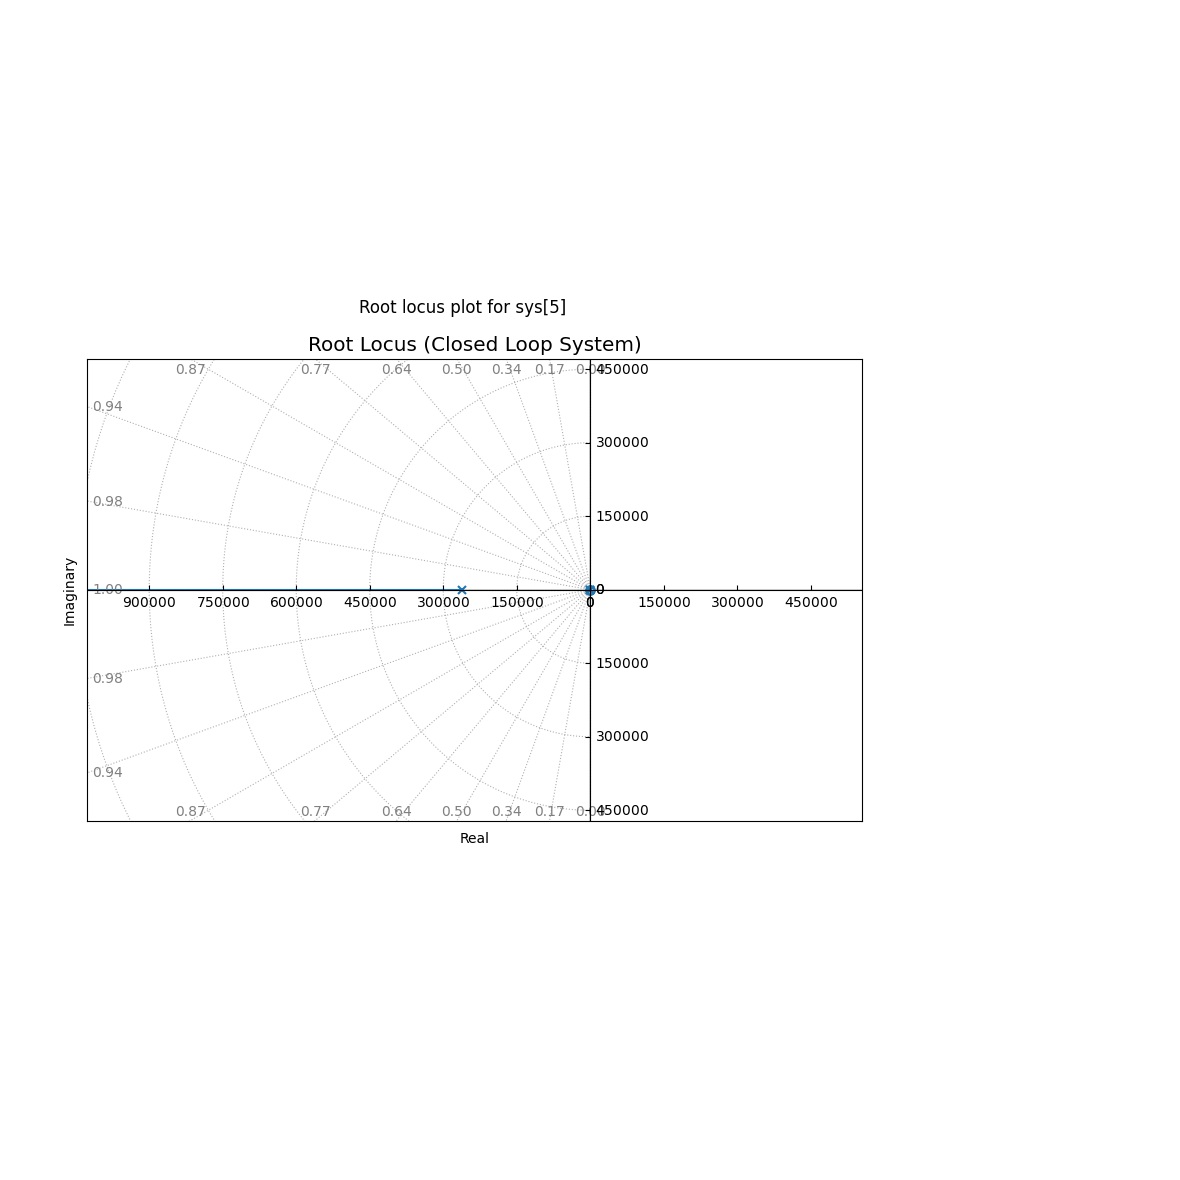

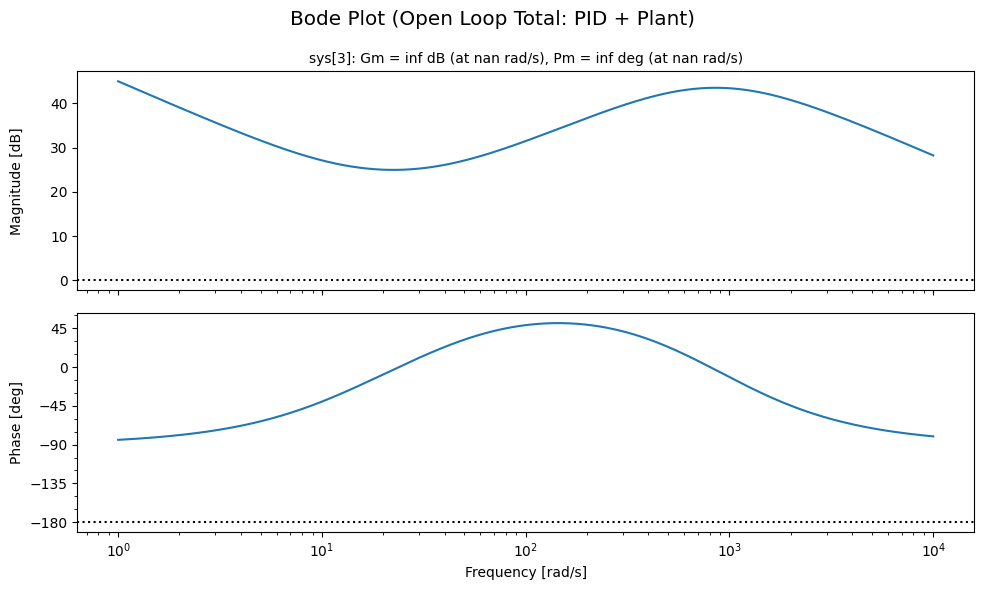

In [5]:
print('--- Analisis Skenario 3: Frequency & Stability ---')

# Transfer Function Kontroler PID Ideal
# C(s) = (Kd*s^2 + Kp*s + Ki) / s
num_pid = [Kd, Kp, Ki]
den_pid = [1, 0]
sys_pid = ct.tf(num_pid, den_pid)

# Feedback Gain
Kf = 1.0

# Open Loop Total (L = C * P)
sys_open_loop_total = sys_pid * sys_tf

# Closed Loop (T = L / (1 + L*H))
sys_closed_loop = ct.feedback(sys_open_loop_total, Kf)

# Hitung Poles
cl_poles = ct.poles(sys_closed_loop)

# Urutkan pole
cl_poles_sorted = sorted(cl_poles, key=lambda x: x.real, reverse=True)

# Hitung Margin Stabilitas
gm, pm, wcg, wcp = ct.margin(sys_open_loop_total)
gm_db = 20 * np.log10(gm) if not math.isinf(gm) else float('inf')

# Print Hasil
print('\n[KESTABILAN SISTEM]')
print('Posisi Closed-Loop Poles:')
for i, p in enumerate(cl_poles_sorted):
    print(f'  s{i+1} = {p.real:.4f} + {p.imag:.4f}j')

print('\n[MARGIN STABILITAS]')
print(f'  Gain Margin (GM)  : {gm_db} dB')
if pm is None or math.isnan(pm):
    print(f'  Phase Margin (PM) : N/A')
else:
    print(f'  Phase Margin (PM) : {pm:.4f} deg at {wcp:.2f} rad/s')

# --- PLOTTING ---

# 1. Root Locus
plt.figure()
ct.root_locus(sys_closed_loop)
plt.title('Root Locus (Closed Loop System)')
plt.grid(True)

# 2. Bode Plot
plt.figure()
ct.bode_plot(sys_open_loop_total, dB=True, display_margins=True)
plt.suptitle('Bode Plot (Open Loop Total: PID + Plant)')
plt.show()

Mengevaluasi 4959 kombinasi PID...

[PERINGATAN] Tidak ada parameter yang memenuhi seluruh batasan. Menampilkan yang paling mendekati:
Kp: 19.0000, Ki: 29.0000, Kd: 0.0100
Overshoot: 0.18% | Error SS: 0.0014


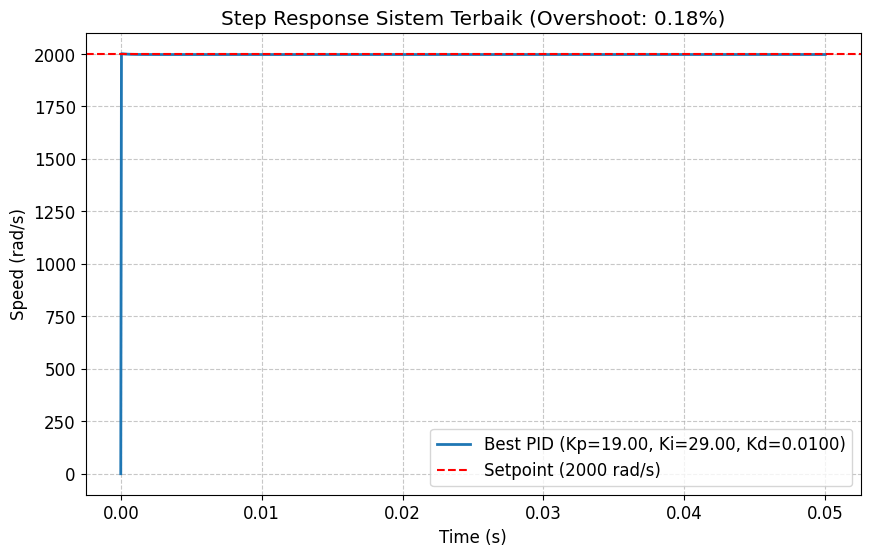

In [11]:
# 1. Fungsi Evaluasi (Diperbarui)
def evaluate_pid(plant, Kp, Ki, Kd, t_final=0.05, n_points=1000):
    # C(s) = Kp + Ki/s + Kd*s = (Kd*s^2 + Kp*s + Ki)/s
    num_c = [Kd, Kp, Ki]
    den_c = [1, 0]
    sys_pid = ct.tf(num_c, den_c)
    
    # Loop dan Feedback
    loop = ct.series(sys_pid, plant)
    closed_loop = ct.feedback(loop, 1)
    
    # Time response (Unit Step)
    T_eval = np.linspace(0, t_final, n_points)
    t, y = ct.step_response(closed_loop, T_eval)
    
    # PERBAIKAN: Ratakan array y menjadi 1D untuk menghindari nested/object array
    y = np.squeeze(y) 
    
    # Hitung metrik kinerja dan konversi paksa ke float standar
    y_final = float(y[-1])
    ess = float(1.0 - y_final) # steady-state error
    
    peak = float(np.max(y))
    if abs(y_final) > 1e-8:
        percent_overshoot = float(max(0.0, (peak - y_final) / abs(y_final) * 100.0))
    else:
        percent_overshoot = float('inf') if peak > 0 else 0.0
        
    # Cek Stabilitas (Pastikan nilai real pole semuanya negatif) dan konversi ke boolean standar
    poles = ct.poles(closed_loop)
    stable = bool(np.all(np.real(poles) < 0))
    
    # Pastikan tipe data dasar yang dikembalikan
    return {
        'Kp': float(Kp), 
        'Ki': float(Ki), 
        'Kd': float(Kd),
        'ess': ess,
        'percent_overshoot': percent_overshoot,
        'stable': stable
    }

# 2. Setup Rentang Pencarian (Grid)
# Catatan: Jarak/step agak diperlebar agar komputasi di iterasi Pandas tidak terlalu membebani PC.
# Silakan diubah menjadi `np.arange(0.1, 50, 0.01)` sesuai kebutuhan akurasi Anda.
Kp_list = np.arange(1.0, 20.0, 1.0)
Ki_list = np.arange(1.0, 30.0, 1.0)
Kd_list = np.arange(0.01, 0.1, 0.01)

# 3. Setup Batasan (Constraints) yang Diharapkan
constraints = {
    'max_ess': 0.00,            # Maksimum error steady-state (5%)
    'max_overshoot_pct': 0.0,  # Maksimum overshoot (10%)
    'stable': True              # Sistem wajib stabil
}

print(f"Mengevaluasi {len(Kp_list)*len(Ki_list)*len(Kd_list)} kombinasi PID...")

# 4. Looping Pencarian Utama
rows = []
for Kp, Ki, Kd in itertools.product(Kp_list, Ki_list, Kd_list):
    # Evaluasi kombinasi (memanggil sys_tf dari cell notebook Anda)
    metrics = evaluate_pid(sys_tf, Kp, Ki, Kd, t_final=0.05)
    
    # Cek apakah memenuhi batasan (Constraint Check)
    ok = True
    if abs(metrics['ess']) > constraints['max_ess']:
        ok = False
    if metrics['percent_overshoot'] > constraints['max_overshoot_pct']:
        ok = False
    if constraints['stable'] and not metrics['stable']:
        ok = False
        
    metrics['meets_constraints'] = ok
    rows.append(metrics)

# 5. Olah Data dan Penentuan Terbaik menggunakan Pandas
df = pd.DataFrame(rows)
df['abs_ess'] = df['ess'].abs()

# Sortir: Prioritas utama adalah "memenuhi batasan", lalu "Error terkecil", terakhir "Overshoot terkecil"
df = df.sort_values(by=['meets_constraints', 'abs_ess', 'percent_overshoot'],
                    ascending=[False, True, True])
df = df.reset_index(drop=True)

# Ambil baris pertama (terbaik)
best_pid = df.iloc[0]

if best_pid['meets_constraints']:
    print(f"\n[SUKSES] Parameter PID Terbaik Ditemukan:")
else:
    print(f"\n[PERINGATAN] Tidak ada parameter yang memenuhi seluruh batasan. Menampilkan yang paling mendekati:")

print(f"Kp: {best_pid['Kp']:.4f}, Ki: {best_pid['Ki']:.4f}, Kd: {best_pid['Kd']:.4f}")
print(f"Overshoot: {best_pid['percent_overshoot']:.2f}% | Error SS: {best_pid['abs_ess']:.4f}")

# 6. Simulasi & Visualisasi terhadap Setpoint (2000 rad/s)
sys_pid_best = ct.tf([best_pid['Kd'], best_pid['Kp'], best_pid['Ki']], [1, 0])
sys_cl_best = ct.feedback(ct.series(sys_pid_best, sys_tf), 1)

setpoint = 2000
T_eval = np.linspace(0, 0.05, 1000)
t, y = ct.step_response(sys_cl_best, T_eval)
y_scaled = y * setpoint # Skalakan ke Setpoint

plt.figure(figsize=(10, 6))
plt.plot(t, y_scaled, label=f"Best PID (Kp={best_pid['Kp']:.2f}, Ki={best_pid['Ki']:.2f}, Kd={best_pid['Kd']:.4f})", linewidth=2)
plt.axhline(setpoint, color='r', linestyle='--', label=f'Setpoint ({setpoint} rad/s)')
plt.title(f"Step Response Sistem Terbaik (Overshoot: {best_pid['percent_overshoot']:.2f}%)")
plt.xlabel('Time (s)')
plt.ylabel('Speed (rad/s)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Mengevaluasi 54929 kombinasi PID dengan Anti-Windup...


/tmp/ipykernel_10070/2242250439.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_curr = float(C @ x)



[SUKSES] Parameter PID Terbaik (Berdasarkan Skor Kombinasi):
Kp: 6.00, Ki: 59.00, Kd: 0.0050
Overshoot    : 0.00%
Error SS     : 4.19%
Rise Time    : 0.0051 s
Settling Time: 0.0500 s
Total Score  : 59.29


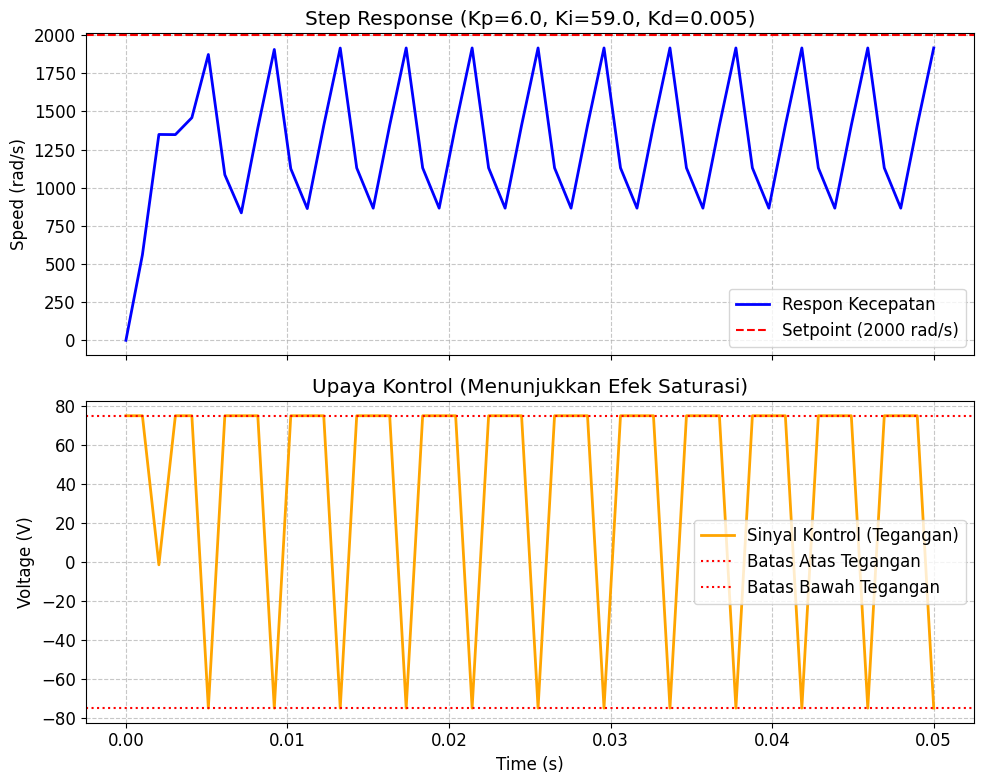

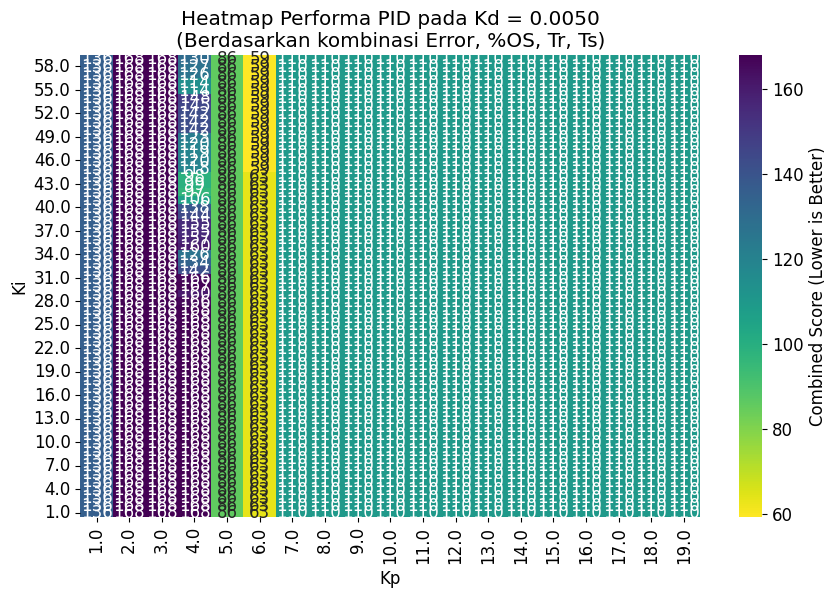

In [16]:
# Konversi Plant ke State-Space Diskrit
# Membutuhkan sys_tf yang telah didefinisikan pada cell sebelumnya
dt = 0.001       # Sampling time 1 ms
t_final = 0.05   # Waktu simulasi 50 ms
setpoint = 2000.0
u_min, u_max = -75.0, 75.0 # Batas Tegangan Input Motor (-24V sd 24V)

sys_ss = ct.ss(sys_tf)
sys_d = ct.sample_system(sys_ss, dt)
A, B, C, D = sys_d.A, sys_d.B, sys_d.C, sys_d.D

# Fungsi Simulasi dengan Saturasi & Anti-Windup (Clamping Method)
def simulate_pid_aw(Kp, Ki, Kd):
    n_steps = int(t_final / dt)
    t = np.linspace(0, t_final, n_steps)
    y = np.zeros(n_steps)
    u_arr = np.zeros(n_steps)
    
    x = np.zeros((sys_d.nstates, 1)) # Initial state
    
    integral = 0.0
    prev_error = 0.0
    
    for i in range(n_steps):
        y_curr = float(C @ x)
        y[i] = y_curr
        
        error = setpoint - y_curr
        
        P = Kp * error
        derivative = (error - prev_error) / dt
        D_term = Kd * derivative
        
        I_temp = integral + (error * dt)
        
        u_unbounded = P + (Ki * I_temp) + D_term
        
        u_sat = max(u_min, min(u_max, u_unbounded))
        u_arr[i] = u_sat
        
        if u_unbounded != u_sat and np.sign(error) == np.sign(u_sat):
            pass 
        else:
            integral = I_temp 
            
        prev_error = error
        x = A @ x + B * u_sat
        
    return t, y, u_arr

# Fungsi Evaluasi Metrik Lengkap
def evaluate_metrics(Kp, Ki, Kd):
    t, y, u_arr = simulate_pid_aw(Kp, Ki, Kd)
    
    y_final = y[-1]
    ess_val = abs(setpoint - y_final) / setpoint
    
    peak = np.max(y)
    overshoot_val = max(0.0, (peak - setpoint) / setpoint * 100.0)
    
    idx_90 = np.where(y >= 0.9 * setpoint)[0]
    rise_time = t[idx_90[0]] if len(idx_90) > 0 else t[-1]
    
    tolerance = 0.02 * setpoint
    idx_outside = np.where(np.abs(y - setpoint) > tolerance)[0]
    settling_time = t[idx_outside[-1]] if len(idx_outside) > 0 else t[0]
    if len(idx_outside) == len(y):
        settling_time = t_final
        
    score = (ess_val * 100.0) + overshoot_val + (rise_time * 1000.0) + (settling_time * 1000.0)
    
    return {
        'Kp': Kp, 'Ki': Ki, 'Kd': Kd,
        'ess_pct': ess_val * 100,
        'overshoot_pct': overshoot_val,
        'rise_time': rise_time,
        'settling_time': settling_time,
        'score': score
    }

# Setup Grid Pencarian
Kp_list = np.arange(1.0, 20.0, 1.0)
Ki_list = np.arange(1.0, 60.0, 1.0)
Kd_list = np.arange(0.001, 0.05, 0.001)

print(f"Mengevaluasi {len(Kp_list)*len(Ki_list)*len(Kd_list)} kombinasi PID dengan Anti-Windup...")

rows = [evaluate_metrics(Kp, Ki, Kd) for Kp, Ki, Kd in itertools.product(Kp_list, Ki_list, Kd_list)]
df = pd.DataFrame(rows)

df = df.sort_values(by='score', ascending=True).reset_index(drop=True)
best_pid = df.iloc[0]

print("\n[SUKSES] Parameter PID Terbaik (Berdasarkan Skor Kombinasi):")
print(f"Kp: {best_pid['Kp']:.2f}, Ki: {best_pid['Ki']:.2f}, Kd: {best_pid['Kd']:.4f}")
print(f"Overshoot    : {best_pid['overshoot_pct']:.2f}%")
print(f"Error SS     : {best_pid['ess_pct']:.2f}%")
print(f"Rise Time    : {best_pid['rise_time']:.4f} s")
print(f"Settling Time: {best_pid['settling_time']:.4f} s")
print(f"Total Score  : {best_pid['score']:.2f}")

# Simulasi Respon Terbaik
t_best, y_best, u_best = simulate_pid_aw(best_pid['Kp'], best_pid['Ki'], best_pid['Kd'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(t_best, y_best, label='Respon Kecepatan', color='blue', linewidth=2)
ax1.axhline(setpoint, color='red', linestyle='--', label='Setpoint (2000 rad/s)')
ax1.set_title(f"Step Response (Kp={best_pid['Kp']}, Ki={best_pid['Ki']}, Kd={best_pid['Kd']})")
ax1.set_ylabel('Speed (rad/s)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

ax2.plot(t_best, u_best, label='Sinyal Kontrol (Tegangan)', color='orange', linewidth=2)
ax2.axhline(u_max, color='red', linestyle=':', label='Batas Atas Tegangan')
ax2.axhline(u_min, color='red', linestyle=':', label='Batas Bawah Tegangan')
ax2.set_title("Upaya Kontrol (Menunjukkan Efek Saturasi)")
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Voltage (V)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

# Visualisasi Heatmap
df_slice = df[df['Kd'] == best_pid['Kd']]
pivot_table = df_slice.pivot(index='Ki', columns='Kp', values='score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='viridis_r', cbar_kws={'label': 'Combined Score (Lower is Better)'})
plt.title(f"Heatmap Performa PID pada Kd = {best_pid['Kd']:.4f}\n(Berdasarkan kombinasi Error, %OS, Tr, Ts)")
plt.gca().invert_yaxis()
plt.show()
